In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Idée d'application

# Extract & Load

In [3]:
ls -lh ./data

Le format du paramŠtre est incorrect - "data".


In [4]:
ls 

 Le volume dans le lecteur Y n'a pas de nom.
 Le num‚ro de s‚rie du volume est 0000-0000

 R‚pertoire de Y:\home\dgaillot\code\openclassrooms\openclassrooms\projets\projet_3

29/02/2024  14:50    <DIR>          .
29/02/2024  14:50    <DIR>          ..
23/02/2024  10:14    <DIR>          .ipynb_checkpoints
23/02/2024  10:14                 8 .python-version
23/02/2024  10:22    <DIR>          data
29/02/2024  14:50         1ÿ567ÿ849 Gaillot_Dimitri_1_notebook_nettoyage_032023.ipynb
23/02/2024  10:14           611ÿ258 GAILLOT_Dimitri_1b_notebook_inputing_032023.ipynb
23/02/2024  10:14         1ÿ667ÿ638 Gaillot_Dimitri_2_notebook_exploration_032023.ipynb
23/02/2024  10:14         7ÿ606ÿ747 Gaillot_Dimitri_3_032023.zip
23/02/2024  10:14         1ÿ637ÿ375 Gaillot_Dimitri_3_pr‚sentation_022023.pdf
23/02/2024  10:14    <DIR>          old_
23/02/2024  10:14         9ÿ856ÿ386 openssl-1.1.1o.tar.gz
23/02/2024  10:14         1ÿ791ÿ126 Untitled.ipynb
               8 fichier(s)       24ÿ738ÿ387 oc

In [5]:
path = './data/'
csv_path = path + 'fr.openfoodfacts.org.products.csv'
#csv_path_old = path + 'fr.openfoodfacts.org.products_old.csv'
#df = pd.read_csv('./data/fr.openfoodfacts.org.products.csv', sep='delimiter', header=None)
#df = pd.read_csv(csv_path, on_bad_lines='skip')
df = pd.read_csv(csv_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)
#df_old = pd.read_csv(csv_path_old, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

# Explore

## Functions

In [143]:
def get_df_columns_na(df):
    nan_values = df.isnull().sum()
    nan_percent = nan_values /df.shape[0]*100
    nan_info = pd.concat([nan_values,nan_percent],axis=1)
    nan_info.columns = ['count', 'null_percent']
    nan_info = nan_info.sort_values(by='null_percent',ascending=True)
    return nan_info

In [144]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [145]:
def show_nulls(df, verbose=False):
    df_nulls = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(df_nulls)
    if verbose == True:
        plot_df_xy(df_nulls.reset_index(), 'null_percent', 'index', 7)

## Cardinality 

In [9]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,0000000003087,http://world-fr.openfoodfacts.org/produit/0000000003087/farine-de-ble-noir-ferme-t-y-r-nao,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,NaN,NaN,Ferme t'y R'nao,ferme-t-y-r-nao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded","en:to-be-completed,en:nutrition-facts-to-be-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","A compléter,Informations nutritionnelles à compléter,Ingrédients à compléter,Date limite à compléter,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité complétée,Nom du produit complete,Photos à valider,Photos envoyées",NaN,

In [10]:
df.shape

(320772, 162)

In [11]:
#df.dtypes

In [12]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320772 entries, 0 to 320771
Data columns (total 162 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    code                                        object 
 1    url                                         object 
 2    creator                                     object 
 3    created_t                                   object 
 4    created_datetime                            object 
 5    last_modified_t                             object 
 6    last_modified_datetime                      object 
 7    product_name                                object 
 8    generic_name                                object 
 9    quantity                                    object 
 10   packaging                                   object 
 11   packaging_tags                              object 
 12   brands                                      object 
 13   brands_tags 

In [13]:
df.describe()

,no_nutriments,additives_n,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,nutrition_grade_uk,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
count,0.0,248939.000000,248939.000000,0.0,248939.000000,0.0,0.0,2.611130e+05,857.000000,243891.000000,229554.000000,0.0,0.0,1.0,2.000000,4.000000,1.0,1.0,1.0,24.000000,23.000000,0.0,0.0,1.0,0.0,22823.000000,22859.000000,841.000000,186.000000,38.000000,78.000000,188.000000,149.000000,8.000000,24.000000,23.000000,21.000000,13.000000,0.0,1.400000e+01,0.0,0.0,0.0,143298.000000,144090.000000,243588.000000,244971.000000,72.000000,26.000000,38.000000,262.000000,4.000000,11.000000,266.000000,414.000000,200886.000000,259922.000000,27.000000,16.000000,9.000000,255510.000000,255463.000000,4133.000000,137554.000000,34.000000,7057.000000,1340.000000,918.000000,140867.000000,11154.000000,10815.000000,11729.000000,6784.000000,5240.000000,3042.000000,5.300000e+03,330.000000,2483.000000,38.000000,81.000000,24748.000000,158.000000,141050.000000,5845.000000,140462.000000,6253.000000,3929.000000,2106.000000,1620.000000,79.000000,1168.000000,20.000000,11.000000,259.000000,78.000000,29.000000,49.000000,3036.000000,165.000000,948.000000,0.0,268.000000,221210.000000,221210.000000,0.0,0.0
mean,NaN,1.936024,0.019659,NaN,0.055246,NaN,NaN,1.141915e+03,585.501214,12.730379,5.129932,NaN,NaN,7.4,6.040000,36.136182,18.9,8.1,3.0,10.752667,10.673913,NaN,NaN,61.0,NaN,10.425055,6.312493,3.182103,2.250285,3.186553,1.635462,16.229144,3.823819,0.057000,0.153842,0.061567,40.192857,25.123077,NaN,1.357143e-06,NaN,NaN,NaN,0.073476,0.020071,32.073981,16.003484,11.841667,2.878846,25.897368,6.354084,24.325000,12.163636,31.925000,49.790389,2.862111,7.075940,4.658148,2.506250,0.021678,2.028624,0.798815,7.838105,0.000397,0.518715,0.000008,0.056705,0.034219,0.023367,0.325574,0.259007,0.020303,0.023378,0.006898,0.205856,8.938696e-05,0.121290,0.072138,0.013123,0.119052,0.424635,0.092638,0.125163,0.617282,0.003652,0.534143,0.007950,0.025794,0.003014,0.012161,0.003126,0.001690,0.000401,0.000427,1.594563,0.145762,6.425698,31.458587,15.412121,49.547785,NaN,341.700764,9.165535,9.058049,NaN,NaN
std,NaN,2.502019,0.140524,NaN,0.269207,NaN,NaN,6.447154e+03,712.809943,17.578747,8.014238,NaN,NaN,NaN,0.226274,24.101433,NaN,NaN,NaN,4.019993,3.379647,NaN,NaN,NaN,NaN,17.0761

### time format

In [14]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

    created_t last_modified_t
0  1474103866      1474103893
1  1489069957      1489069957
2  1489069957      1489069957
3  1489055731      1489055731
4  1489055653      1489055653

        created_datetime last_modified_datetime
0  2016-09-17T09:17:46Z   2016-09-17T09:18:13Z
1  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
2  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
3  2017-03-09T10:35:31Z   2017-03-09T10:35:31Z
4  2017-03-09T10:34:13Z   2017-03-09T10:34:13Z


=> "_t" fields are in UNIX timestamp format

=> "_datetime" fiels are in UTC ISO 8601 format

=> they are duplicates, might need to only keep the ISO 8601

In [15]:
def clean_datetime(df):
    columns = df.columns
    columns_result = []
    for column in columns:
        if column[-2:] == '_t':
            df = df.drop(column, axis=1)     
    return df

In [16]:
df = clean_datetime(df)

In [17]:
df.shape

(320772, 160)

In [18]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320772 entries, 0 to 320771
Data columns (total 160 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    code                                        object 
 1    url                                         object 
 2    creator                                     object 
 3    created_datetime                            object 
 4    last_modified_datetime                      object 
 5    product_name                                object 
 6    generic_name                                object 
 7    quantity                                    object 
 8    packaging                                   object 
 9    packaging_tags                              object 
 10   brands                                      object 
 11   brands_tags                                 object 
 12   categories                                  object 
 13   categories_t

In [19]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

        created_datetime last_modified_datetime
0  2016-09-17T09:17:46Z   2016-09-17T09:18:13Z
1  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
2  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
3  2017-03-09T10:35:31Z   2017-03-09T10:35:31Z
4  2017-03-09T10:34:13Z   2017-03-09T10:34:13Z


# Features reduction

## Countries : France

In [20]:
# count distinct values
df.countries.nunique()

1434

In [21]:
# show values
df.countries.unique().tolist()

['en:FR',
 'US',
 'France',
 'en:GB',
 'France, US',
 'Canada',
 'United Kingdom',
 'en:CH',
 'en:ES',
 'Deutschland',
 'en:SI',
 'en:DE',
 'en:IT',
 'en:RO',
 'España',
 'en:AU',
 'en:PT',
 'United States',
 'Germany',
 'Usa',
 'France,Royaume-Uni',
 'UK,France',
 'France,Belgique,Pays-Bas,Royaume-Uni',
 'France,United Kingdom',
 'en:GP',
 'France,UK',
 'États-Unis',
 'Royaume-Uni,France',
 'en:CA',
 nan,
 'en:US,United Kingdom',
 'Switzerland',
 'en:US',
 'en:CA, US',
 'Nederland',
 'en:AU, en:france',
 'Australia',
 'France,Suisse,États-Unis,Canada',
 'États-Unis, en:france, US',
 'Ireland',
 'United Kingdom, US',
 'en:RE, en:france',
 'United States, en:france',
 'en:TW',
 'en:AU, Suisse',
 'Deutschland, en:france',
 'Suisse',
 'en:BR',
 'Belgique,France',
 'en:DO',
 'en:FR, US',
 'Belgique,France,Pays-Bas,Royaume-Uni',
 'France,United States',
 'Australie, US',
 'USA',
 'en:SA',
 'Saudi Arabia',
 'en:AE',
 'en:IQ',
 'en:KW',
 'Republica Moldova',
 'Belgium',
 'en:NC',
 'Singapore'

In [22]:
# should we keep only French related "countries ?"

In [23]:
df['countries'].loc[df['countries'].str.contains('fr', na=False)].nunique()

166

In [24]:
#countries_count = df['countries'].value_counts()
#countries_count.head(25)

countries
US                169928
France             77292
en:FR              16979
Suisse             12314
Deutschland         6161
España              3688
United Kingdom      3247
United States       2248
en:CH               2150
en:BE               1538
en:GB               1507
Australia           1412
en:DE               1276
Россия              1151
en:ES                947
Belgique             802
en:US                761
en:AU                642
en:IT                596
en:CA                569
France, Suisse       506
Portugal             504
Germany              389
Switzerland          360
Italia               331
Name: count, dtype: int64

In [25]:
#countries_NS_count = df['countries'].loc[df['nutrition-score-fr_100g'].notna()].value_counts()
#countries_NS_count.head(25) 

countries
US                     137586
France                  58424
Suisse                   8083
Deutschland              4042
España                   2175
United Kingdom           1419
United States            1304
en:CH                     552
Australia                 459
France, Suisse            424
Belgique                  416
Portugal                  300
Germany                   251
Switzerland               242
France,Suisse             195
en:US                     181
Belgique,France           178
Canada                    170
Italia                    158
en:FR, Suisse             151
Nederland                 141
Germany,Switzerland       130
Spain                     121
Magyarország              107
UK,France                 100
Name: count, dtype: int64

In [26]:
countries_info = pd.DataFrame(countries_count)\
            .merge(pd.DataFrame(countries_NS_count), how ='left', left_on='countries', right_on ='countries')\
            .rename(columns={'count_x': 'rows_count', 'count_y': 'rows_with_nutriscore_count'})\
            .fillna(0)

In [27]:
countries_info.columns

Index(['rows_count', 'rows_with_nutriscore_count'], dtype='object')

In [28]:
countries_info['ratio_with_nutriscore'] = countries_info['rows_with_nutriscore_count'] / countries_info['rows_count']

In [29]:
countries_info.sort_values(by= 'rows_with_nutriscore_count',ascending=False).head(30)

,rows_count,rows_with_nutriscore_count,ratio_with_nutriscore
countries,,,
US,169928,137586.0,0.809672
France,77292,58424.0,0.755887
Suisse,12314,8083.0,0.656407
Deutschland,6161,4042.0,0.656062
España,3688,2175.0,0.589751
United Kingdom,3247,1419.0,0.437019
United States,2248,1304.0,0.580071
en:CH,2150,552.0,0.256744
Australia,1412,459.0,0.325071


ValueError: Input data must be a pandas object to reorder

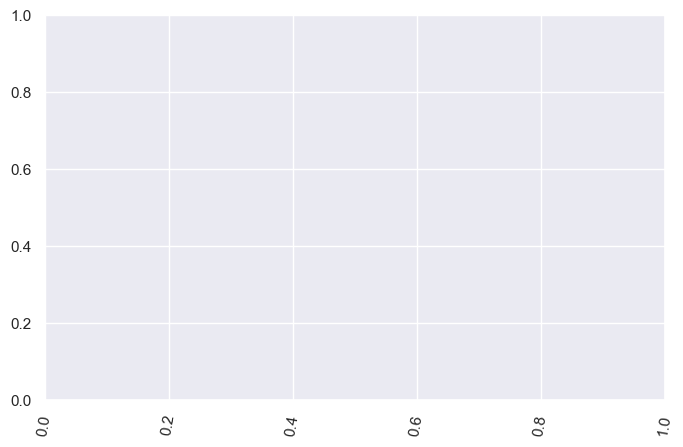

In [215]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
ax = sns.countplot(data=pd.DataFrame(countries_info['rows_with_nutriscore_count'])
             #,x="pnns_groups_1"
             ,order = countries_info['rows_with_nutriscore_count'].value_counts(ascending=False).index
            )
var = ax.bar_label(ax.containers[0], rotation=0, padding=2)

<Axes: xlabel='countries'>

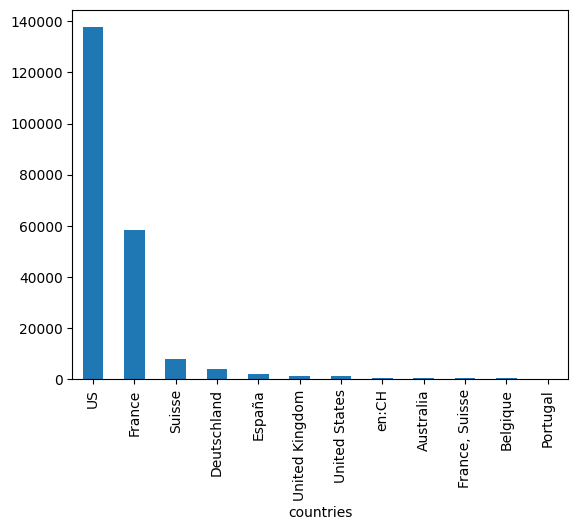

In [30]:
countries_info['rows_with_nutriscore_count']\
.sort_values(ascending=False)\
.head(12)\
.plot(kind='bar')

In [31]:
#top_fr = countries_fr_count.head(3).index.to_list()
#top_fr

In [32]:
#df.loc[df['countries'].isin(top_fr)].shape

In [33]:
df.loc[df['countries'] == 'France'].shape[0] / df.shape[0]

0.24095619318394373

In [34]:
df.loc[df['countries'] == 'France'].loc[df['nutrition-score-fr_100g'].notna()].shape[0] / df.shape[0]

0.1821355978701383

In [35]:
df.loc[df['countries'] == 'España'].loc[df['nutrition-score-fr_100g'].notna()]

,code,url,creator,created_datetime,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
51837,0041570112717,http://world-fr.openfoodfacts.org/produit/0041570112717/leche-de-almendras-original-almond-breeze,javichu,2016-01-24T22:52:27Z,2016-01-24T23:19:56Z,Leche de almendras Original,Leche de almendras con calcio,1 l,"Tetra Brik,Ultrapasteurizado","tetra-brik,ultrapasteurizado","Almond Breeze,Blue Diamond Almonds,//Propiedad de://,Blue Diamond Growers Corporation","almond-breeze,blue-diamond-almonds,propiedad-de,blue-diamond-growers-corporation","Alimentos y bebidas de origen vegetal,Bebidas,Alimentos de origen vegetal,Lácteos,Frutos de cáscara y derivados,Bebidas de origen vegetal,Leches,Leches vegetales,Leches de almendras,Non-sugared beverages,Leches de frutos de cáscara","en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:dairies,en:plant-based-beverages,en:milk-substitute,en:milks,en:nuts-and-their-products,en:plant-milks,en:nut-milks,en:almond-milks,en:non-sugared-beverages","Aliments et boissons à base de végétaux,Boissons,Aliments d'origine végétale,Produits laitiers,Boissons à base de végétaux,Substitut du lait,Laits,Fruits à coques et dérivés,Laits végétaux,Laits de fruits à coques,Laits d'amande,Boissons non sucrées","[ALMENDRAS],California,Estados Unidos","almendras,california,estados-unidos","Agrón (parroquia),Ames,La Coruña (provincia),Galicia,España","agron-parroquia,ames,la-coruna-provincia,galicia,espana","Vegetariano,FSC,Vegano,Sin gluten,Si

In [36]:
df = df.loc[df['countries'] == 'France'].loc[df['nutrition-score-fr_100g'].notna()]

In [37]:
df.shape

(58424, 160)

## Rows with nutriscore

In [38]:
# keep only rows with nutriscore

#df = df.loc[df['nutriscore_score'].notna()]

In [39]:
#df.filter(like='score', axis=1).columns

In [40]:
#df = df.loc[df['nutrition-score-fr_100g'].notna()]

In [41]:
#df.columns.values

## Categories : replace 'unknown' by nans

In [42]:
df[['pnns_groups_1', 'pnns_groups_2']].isna().sum()

pnns_groups_1    13824
pnns_groups_2    13733
dtype: int64

In [43]:
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'unknown'].count()

6843

In [44]:
df['pnns_groups_1'].loc[df['pnns_groups_2'] == 'unknown'].count()

6843

In [45]:
#print(df.apply(lambda col: col.unique()))

In [46]:
df['pnns_groups_1'].nunique()

13

In [47]:
df['pnns_groups_2'].nunique()

40

In [48]:
df['main_category_fr'].nunique()

909

In [49]:
df['pnns_groups_1'].head(50)

190                        NaN
191                        NaN
226                  Beverages
234                        NaN
240                  Beverages
242              Sugary snacks
279              Sugary snacks
283              Sugary snacks
299              Sugary snacks
301              Sugary snacks
307                        NaN
428              Sugary snacks
493                    unknown
495                        NaN
508              Sugary snacks
509                    unknown
523                        NaN
552                        NaN
564      Fruits and vegetables
632                        NaN
664                  Beverages
789                    unknown
1571                       NaN
6757                       NaN
7386                       NaN
9744             Sugary snacks
9890             Sugary snacks
11082                      NaN
11179                      NaN
11239                      NaN
11244                      NaN
11272            Sugary snacks
11276   

In [50]:
df['pnns_groups_1'].unique()

array([nan, 'Beverages', 'Sugary snacks', 'unknown',
       'Fruits and vegetables', 'Salty snacks', 'Composite foods',
       'Fat and sauces', 'Cereals and potatoes', 'fruits-and-vegetables',
       'Milk and dairy products', 'Fish Meat Eggs', 'sugary-snacks',
       'cereals-and-potatoes'], dtype=object)

In [51]:
df.shape

(58424, 160)

In [52]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
unknown                    6843
Sugary snacks              6779
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4745
Fish Meat Eggs             4528
Beverages                  4131
Fat and sauces             2688
Fruits and vegetables      2631
Salty snacks               1709
fruits-and-vegetables       415
sugary-snacks               358
cereals-and-potatoes          1
Name: count, dtype: int64

In [53]:
df['pnns_groups_2'].value_counts()

pnns_groups_2
unknown                             6843
One-dish meals                      3939
Biscuits and cakes                  3021
Cereals                             2378
Sweets                              2181
Processed meat                      2128
Cheese                              2097
Dressings and sauces                1812
Milk and yogurt                     1664
Chocolate products                  1577
Fish and seafood                    1511
Appetizers                          1343
Fruit juices                        1259
Sweetened beverages                 1253
Non-sugared beverages               1207
Vegetables                          1106
Bread                               1029
Fruits                               904
Breakfast cereals                    887
Fats                                 876
Meat                                 789
Dairy desserts                       638
Sandwich                             585
Ice cream                            464
Le

In [54]:
df[['pnns_groups_1', 'pnns_groups_2']] = df[['pnns_groups_1', 'pnns_groups_2']].replace('unknown', np.nan)

In [55]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
Sugary snacks              6779
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4745
Fish Meat Eggs             4528
Beverages                  4131
Fat and sauces             2688
Fruits and vegetables      2631
Salty snacks               1709
fruits-and-vegetables       415
sugary-snacks               358
cereals-and-potatoes          1
Name: count, dtype: int64

In [56]:
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'unknown'].count()

0

In [57]:
df['pnns_groups_1'].loc[df['pnns_groups_2'] == 'unknown'].count()

0

In [58]:
df[['pnns_groups_1', 'pnns_groups_2']].isna().sum()

pnns_groups_1    20667
pnns_groups_2    20576
dtype: int64

In [59]:
df['pnns_groups_1'].value_counts().index.to_list()

['Sugary snacks',
 'Composite foods',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs',
 'Beverages',
 'Fat and sauces',
 'Fruits and vegetables',
 'Salty snacks',
 'fruits-and-vegetables',
 'sugary-snacks',
 'cereals-and-potatoes']

In [60]:
df['pnns_groups_1'].value_counts(ascending=True).index

Index(['cereals-and-potatoes', 'sugary-snacks', 'fruits-and-vegetables',
       'Salty snacks', 'Fruits and vegetables', 'Fat and sauces', 'Beverages',
       'Fish Meat Eggs', 'Cereals and potatoes', 'Milk and dairy products',
       'Composite foods', 'Sugary snacks'],
      dtype='object', name='pnns_groups_1')

### Categories

####  Duplicates Main categories

In [61]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
Sugary snacks              6779
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4745
Fish Meat Eggs             4528
Beverages                  4131
Fat and sauces             2688
Fruits and vegetables      2631
Salty snacks               1709
fruits-and-vegetables       415
sugary-snacks               358
cereals-and-potatoes          1
Name: count, dtype: int64

In [62]:
# check duplicate sugary-snacks
df[df['pnns_groups_1'] == 'sugary-snacks'].head()

code  \
112772  0202577010172   
112773  0202581010823   
176591  2000000042658   
177226       20022686   
177640       20065478   

                                                                                                                url  \
112772                             http://world-fr.openfoodfacts.org/produit/0202577010172/croissants-carrefour-bio   
112773                      http://world-fr.openfoodfacts.org/produit/0202581010823/pains-au-chocolat-carrefour-bio   
176591              http://world-fr.openfoodfacts.org/produit/2000000042658/brioche-tranchee-xxl-maitre-jean-pierre   
177226                   http://world-fr.openfoodfacts.org/produit/20022686/10-pains-au-chocolat-maitre-jean-pierre   
177640  http://world-fr.openfoodfacts.org/produit/20065478/brioche-pur-beurre-aux-oeufs-tranchee-maitre-jean-pierre   

                           creator      created_datetime  \
112772                  agamitsudo  2016-05-25T10:59:24Z   
112773                  agamitsudo  2016-05-25T10:59:58Z   
176591                     nouky20  2017-02-18T07:08:51Z   
177226  openfoodfacts-contributors  2015-04-09T19:33:55Z   
177640  openfoodfacts-contributors  2013-05-16T18:06:35Z   

       last_modified_datetime                           product_name  \
112772   2016-07-19T11:42:39Z                             Croissants   
112773   2017-03-11T10:38:17Z                      Pains au chocolat   
176591   2017-04-15T06:13:53Z                 Brioche Tranchée (XXL)   
177226   2016-06-02T14:30:34Z                   10 pains au chocolat   
177640   2016-10-28T10:43:35Z  Brioche Pur beurre-Aux oeufs-Tranchée   

                           generic_name quantity  \
112772                              NaN    120 g   
112773                              NaN    130 g   
176591  Brioche tranchée aux œufs frais     700g   
177226                 pain au chocolat    450 g   
177640      Brioche tranchée pur beurre    500 g   

                                packaging                     packaging_tags  \
112772                   Sachet,Plastique                   sachet,plastique   
112773                   sachet,plastique                   sachet,plastique   
176591               Sachet,plastique,xxl               sachet,plastique,xxl   
177226      Sachets plastique individuels      sachets-plastique-individuels   
177640  Sachet plastique,sachet plastique  sachet-plastique,sachet-plastique   

                         brands              brands_tags  \
112772  Carrefour Bio,Carrefour  carrefour-bio,carrefour   
112773  Carrefour Bio,Carrefour  carrefour-bio,carrefour   
176591  Maître Jean Pierre,Lidl  maitre-jean-pierre,lidl   
177226  Maître Jean-Pierre,Lidl  maitre-jean-pierre,lidl   
177640       Maître Jean Pierre       maitre-jean-pierre   

                                                                                                                                                                                       categories  \
112772                                                                                                                                                                                 Croissants   
112773                                                                                                                                                                          Pains au chocolat   
176591  Aliments et boissons à base de végétaux,Aliments d'origine végétale,Petit-déjeuners,Céréales et pommes de terre,Snacks sucrés,Pains,Viennoiseries,Brioches,Brioches tranchées,Viennoisere   
177226                                                                                                                                                                           Pain au chocolat   
177640                                                                                                                                       Petit-déjeuners,Snacks sucrés,Viennoiseries,Brioches   

                   

In [63]:
# check duplicate cereals-and-potatoes
df[df['pnns_groups_1'] == 'cereals-and-potatoes']

,code,url,creator,created_datetime,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
218773,3270160046201,http://world-fr.openfoodfacts.org/produit/3270160046201/mais-doux-en-epis-picard,agamitsudo,2013-09-03T17:24:45Z,2017-02-26T13:22:44Z,Maïs doux en épis,Maïs doux,600 g,"Plastique,Surgelé","plastique,surgele",Picard,picard,"Aliments et boissons à base de végétaux,Aliments d'origine végétale,Céréales et pommes de terre,Céréales et dérivés,Surgelés,Aliments à base de plantes surgelés,Céréales surgelés,Maïs surgelé","en:plant-based-foods-and-beverages,en:plant-based-foods,en:cereals-and-potatoes,en:cereals-and-their-products,en:frozen-foods,en:frozen-plant-based-foods,en:frozen-cereals,en:frozen-corn","Aliments et boissons à base de végétaux,Aliments d'origine végétale,Céréales et pommes de terre,Céréales et dérivés,Surgelés,Aliments à base de plantes surgelés,Céréales surgelés,Maïs surgelé","France,Landes,Sud Ouest","france,landes,sud-ouest",Espagne,espagne,"Peu ou pas de sel,Sans sel ajouté","en:low-or-no-salt,en:no-added-salt","Peu ou pas de sel,Sans sel ajouté",NaN,NaN,NaN,NaN,NaN,"France,Beynost",Picard,France,en:france,France,maïs,NaN,NaN,NaN,NaN,NaN,200 g,NaN,0.0,[ mais -> fr:mais ],NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,a,cereals-and-potatoes,cereals,"en:to-be-checked, en:complete, en:nutrition-facts-completed, en:ingredients-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-completed, en:categories-completed, en:brands-

In [64]:
# replace 'sugary-snacks' => 'Cereals and potatoes'
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'sugary-snacks'] = 'Sugary snacks'

# replace 'cereals-and-potatoes' => 'Cereals and potatoes'
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'cereals-and-potatoes'] = 'Cereals and potatoes'

# replace 'fruits-and-vegetables'
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'fruits-and-vegetables'] = 'Fruits and vegetables'

In [65]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
Sugary snacks              7137
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4746
Fish Meat Eggs             4528
Beverages                  4131
Fruits and vegetables      3046
Fat and sauces             2688
Salty snacks               1709
Name: count, dtype: int64

#### Categories : merge mis-named categories

In [66]:
#sm_df[sm_df['pnns_groups_2'] == 'pastries']

In [67]:
# replace 'sugary-snacks' => 'Sugary snacks'
#sm_df['pnns_groups_2'].loc[sm_df['pnns_groups_2'] == 'pastries'] = 'Pastries'

In [68]:
#sm_df['pnns_groups_2'].value_counts()

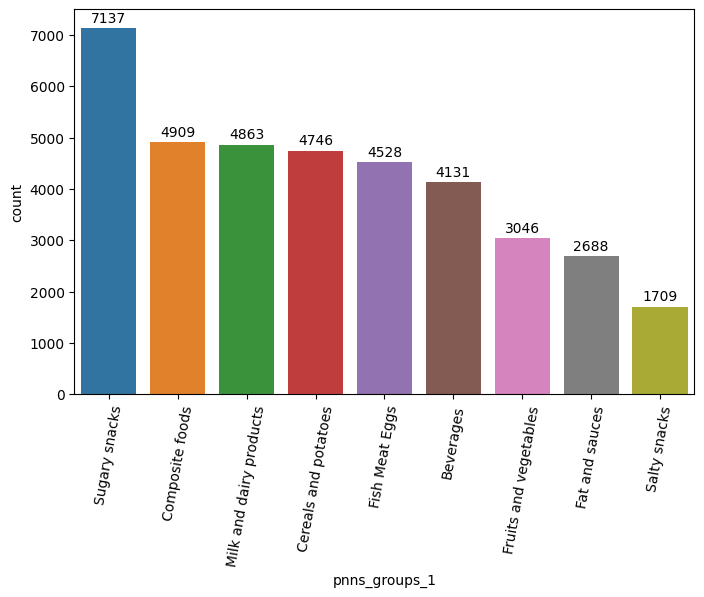

In [72]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
ax = sns.countplot(data=df
             ,x="pnns_groups_1"
             ,order = df['pnns_groups_1'].value_counts(ascending=False).index
            )
var = ax.bar_label(ax.containers[0], rotation=0, padding=2)

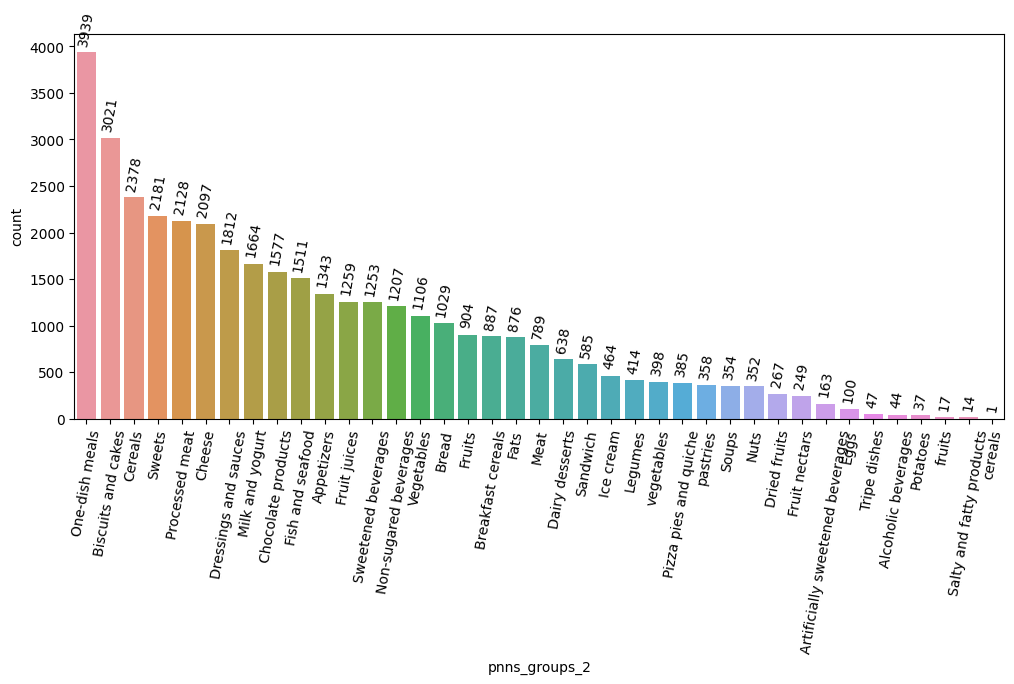

In [75]:
plt.figure(figsize=(12, 5))
plt.xticks(rotation=80)
ax = sns.countplot(data=df
             ,x="pnns_groups_2"
             ,order = df['pnns_groups_2'].value_counts(ascending=False).index
            )
#var = ax.bar_label(ax.containers[0], rotation=80, padding=4)
ax.set_xticklabels(by_school.get_xticklabels(), 
                          rotation=90, 
                          horizontalalignment='right')

In [71]:
df.shape

(58424, 160)

## Mostly empty columns > removal

In [78]:
nan_values = df.isnull().sum()
nan_percent = nan_values /df.shape[0]*100
#nan_values.sort_values(ascending=True)

In [79]:
nan_info = pd.concat([nan_values,nan_percent],axis=1)
nan_info.columns = ['count', 'null_percent']

nan_info = nan_info.sort_values(by='null_percent',ascending=True)
nan_info

,count,null_percent
code,0,0.000000
states_fr,0,0.000000
states_tags,0,0.000000
states,0,0.000000
nutrition_grade_fr,0,0.000000
countries_fr,0,0.000000
countries_tags,0,0.000000
countries,0,0.000000
nutrition-score-uk_100g,0,0.000000
nutrition-score-fr_100g,0,0.000000


In [80]:
# find columns with -40% missing values

df_fill_mask = nan_info.loc[nan_info["null_percent"] <= 40.0]
mask_columns = df_fill_mask.index

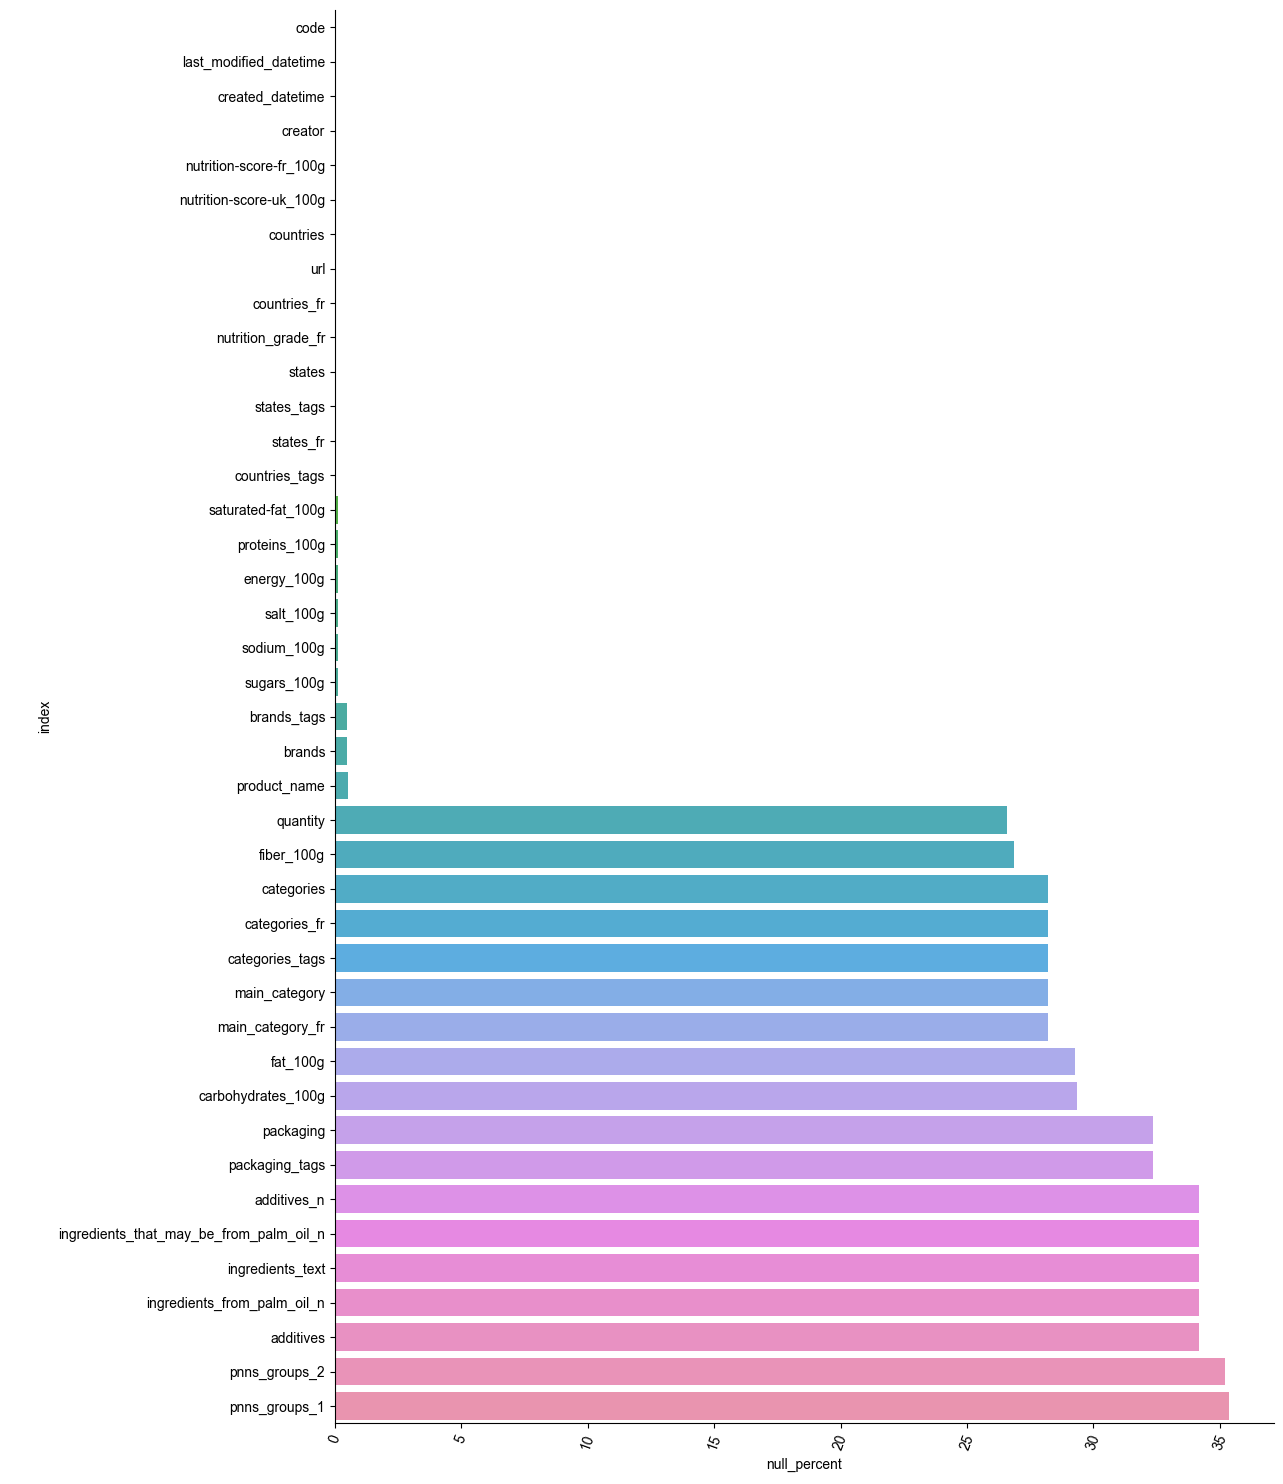

In [81]:
#df_fill_mask
plot_df_xy(df_fill_mask.reset_index().sort_values(by='null_percent',ascending=True), 'null_percent','index', 15)

In [82]:
df[mask_columns].head()

,code,states_fr,states_tags,states,nutrition_grade_fr,countries_fr,countries_tags,countries,nutrition-score-uk_100g,nutrition-score-fr_100g,url,creator,created_datetime,last_modified_datetime,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,brands,brands_tags,product_name,quantity,fiber_100g,categories,categories_fr,categories_tags,main_category,main_category_fr,fat_100g,carbohydrates_100g,packaging,packaging_tags,additives_n,ingredients_that_may_be_from_palm_oil_n,ingredients_text,ingredients_from_palm_oil_n,additives,pnns_groups_2,pnns_groups_1
190,0000010187319,"A compléter,Informations nutritionnelles complétées,Ingrédients à compléter,Date limite à compléter,en:Packaging-code-to-be-completed,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité à compléter,Nom du produit complete,Photos à valider,Photos envoyées","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:packaging-code-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-to-be-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","en:to-be-completed, en:nutrition-facts-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-to-be-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded",d,France,en:france,France,14.0,14.0,http://world-fr.openfoodfacts.org/produit/0000010187319/mini-confettis-alice-delice,kiliweb,2017-02-17T10:05:54Z,2017-02-17T10:05:54Z,0.6,1753.0,0.0100,0.003937,87.7,0.8,Alice Délice,alice-delice,Mini Confettis,NaN,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,0000010207260,"A compléter,Informations nutritionnelles complétées,Ingrédients à compléter,Date limite à compléter,en:Packaging-code-to-be-completed,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité à compléter,Nom du produit complete,Photos à valider,Photos envoyées","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:packaging-code-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-to-be-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","en:to-be-completed, en:nutrition-facts-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-to-be-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded",d,France,en:france,France,14.0,14.0,http://world-fr.openfoodfacts.org/produit/0000010207260/praline-amande-et-noisette-alice-delice,kiliweb,2017-03-22T17:17:11Z,2017-03-22T17:29:17Z,9.5,2406.0,0.0030,0.001181,50.3,2.9,Alice Délice,alice-delice,Praliné Amande Et Noisette,NaN,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226,0000040608754,"A vérifier,Complet,Informations nutritionnelles complétées,Ingrédients complétés,Date limite à compléter,Caractéristiques complétées,Catégories complétées,Marques complétées,Emballage complété,Quantité complétée,Nom du produit complete,Photos validées,Photos envoyées","en:to-be-checked,en:complete,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-be-completed,en:characteristics-completed,en:categories-completed,en:brands-completed,en:packaging-completed,en:quantity-completed,en:product-name-completed,en:photos-validated,en:photos-uploaded","en:to-be-checked, en:complete, en:nut

In [83]:
df[mask_columns].columns.to_list()

['code',
 'states_fr',
 'states_tags',
 'states',
 'nutrition_grade_fr',
 'countries_fr',
 'countries_tags',
 'countries',
 'nutrition-score-uk_100g',
 'nutrition-score-fr_100g',
 'url',
 'creator',
 'created_datetime',
 'last_modified_datetime',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'brands',
 'brands_tags',
 'product_name',
 'quantity',
 'fiber_100g',
 'categories',
 'categories_fr',
 'categories_tags',
 'main_category',
 'main_category_fr',
 'fat_100g',
 'carbohydrates_100g',
 'packaging',
 'packaging_tags',
 'additives_n',
 'ingredients_that_may_be_from_palm_oil_n',
 'ingredients_text',
 'ingredients_from_palm_oil_n',
 'additives',
 'pnns_groups_2',
 'pnns_groups_1']

In [84]:
columns_to_keep = [
 'code',
# 'states_fr',
# 'states_tags',
# 'states',
 'nutrition_grade_fr',
# 'countries_fr',
# 'countries_tags',
# 'countries',
# 'nutrition-score-uk_100g',
 'nutrition-score-fr_100g',
# 'url',
# 'creator',
# 'created_datetime',
# 'last_modified_datetime',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
# 'brands',
# 'brands_tags',
 'product_name',
# 'quantity',
 'fiber_100g',
# 'categories',
# 'categories_fr',
# 'categories_tags',
# 'main_category',
# 'main_category_fr',
 'fat_100g',
 'carbohydrates_100g',
# 'packaging',
# 'packaging_tags',
# 'additives_n',
# 'ingredients_that_may_be_from_palm_oil_n',
# 'ingredients_text',
# 'ingredients_from_palm_oil_n',
# 'additives',
 'pnns_groups_2',
 'pnns_groups_1'
]

In [85]:
sm_df = df.loc[:,columns_to_keep]

In [86]:
df.shape

(58424, 160)

In [87]:
sm_df.shape

(58424, 15)

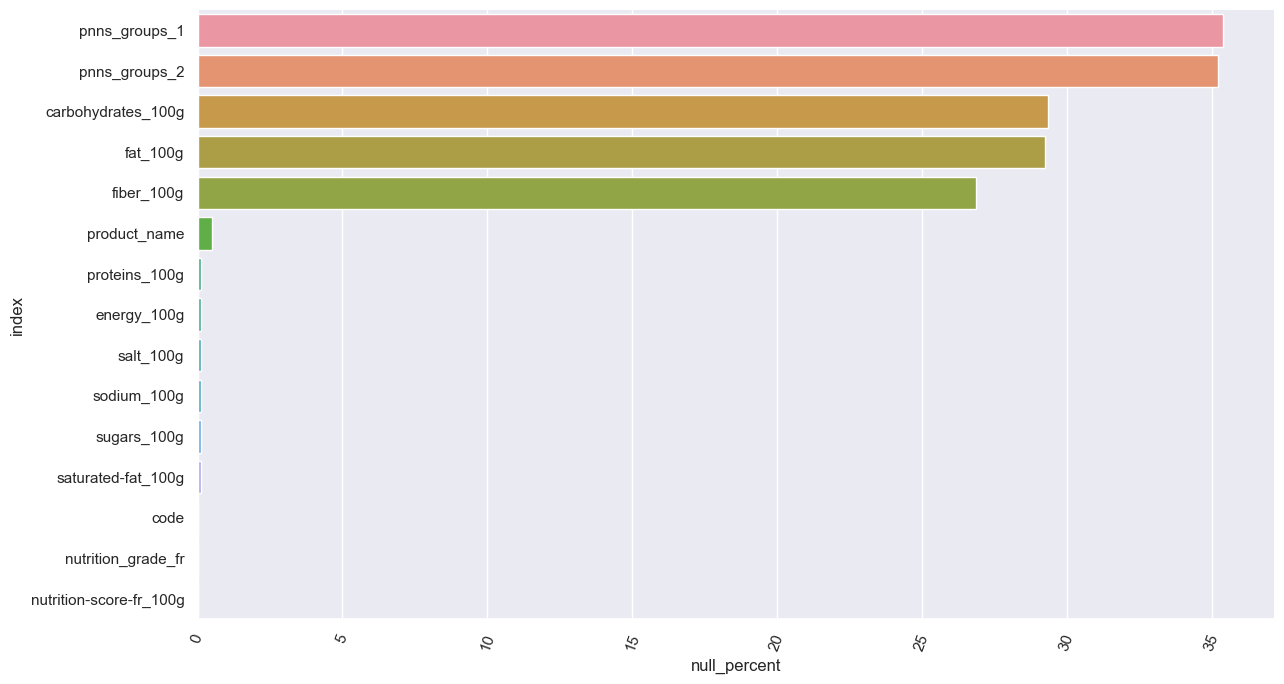

In [88]:
top_sm_df = get_df_columns_na(sm_df).sort_values(by='null_percent',ascending=False)
plot_df_xy(top_sm_df.reset_index(), 'null_percent', 'index', 7)

In [89]:
top_sm_df

,count,null_percent
pnns_groups_1,20667,35.374161
pnns_groups_2,20576,35.218403
carbohydrates_100g,17142,29.340682
fat_100g,17091,29.253389
fiber_100g,15690,26.855402
product_name,297,0.508353
proteins_100g,72,0.123237
energy_100g,72,0.123237
salt_100g,72,0.123237
sodium_100g,72,0.123237


In [148]:
sm_df.head(50)

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
190,0000010187319,d,14.0,0.6,1753.0,0.01000,0.003937,87.7,0.8,Mini Confettis,0.9,NaN,NaN,NaN,NaN
191,0000010207260,d,14.0,9.5,2406.0,0.00300,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
226,0000040608754,e,13.0,0.0,177.0,0.02540,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.00,10.40,Sweetened beverages,Beverages
234,0000069161025,d,15.0,7.5,1079.0,0.80000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
240,0000087177756,e,13.0,0.0,177.0,0.10000,0.039370,10.4,0.0,7Up,NaN,0.00,10.40,Sweetened beverages,Beverages
242,000010,d,12.0,6.0,1900.0,0.66000,0.259843,26.0,2.5,Madeleines nature,1.5,23.00,55.00,Biscuits and cakes,Sugary snacks
279,000030,d,13.0,5.8,1768.0,0.65000,0.255906,28.0,2.5,Cakes Raisins,1.8,19.00,56.00,Biscuits and cakes,Sugary snacks
283,000031,d,12.0,4.9,1670.0,0.60000,0.236220,34.0,2.0,Cakes aux Fruits,1.5,15.00,60.00,Biscuits and cakes,Sugary snacks
299,000050,e,22.0,8.0,1868.0,0.55000,0.216535,39.0,10.0,Financiers aux Amandes,1.7,23.00,51.00,Biscuits and cakes,Sugary snacks
301,000051,e,22.0,8.1,1896.0,0.78000,0.307087,37.0,10.0,Fondants Citron,2.5,24.00,50.00,Biscuits and cakes,Sugary snacks


# Id & replacing wrong values

##  Impossible values (negative / over maximum)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17142     29.340682
fat_100g                 17091     29.253389
fiber_100g               15690     26.855402
product_name               297      0.508353
proteins_100g               72      0.123237
energy_100g                 72      0.123237
salt_100g                   72      0.123237
sodium_100g                 72      0.123237
sugars_100g                 72      0.123237
saturated-fat_100g          72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000
nutrition-score-fr_100g      0      0.000000


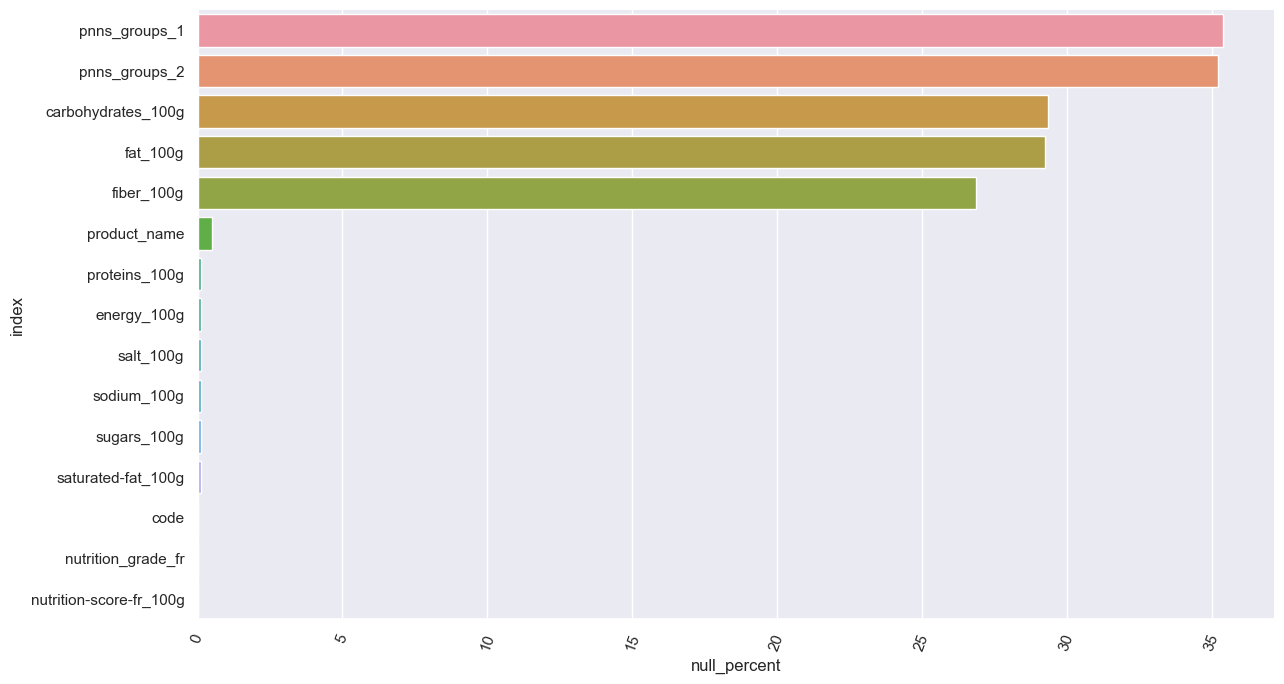

In [149]:
show_nulls(sm_df, verbose=True)

In [150]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,58424.000000,58352.000000,5.835200e+04,58352.000000,58352.000000,58352.000000,58352.000000,42734.000000,41333.000000,41282.000000
mean,8.599445,7.774643,1.177408e+03,1.086048,0.427578,13.198039,5.398200,2.505745,13.265636,27.306794
std,9.018172,7.882460,1.350234e+04,3.827492,1.506836,18.974746,8.560182,4.615174,16.824987,27.162540
min,-15.000000,0.000000,0.000000e+00,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.800000,4.330000e+02,0.080000,0.031496,1.000000,0.300000,0.000000,1.400000,4.000000
50%,8.000000,6.000000,1.033000e+03,0.570000,0.224409,4.000000,1.900000,1.300000,6.900000,14.000000
75%,15.000000,11.000000,1.648000e+03,1.250000,0.492126,17.000000,7.300000,3.100000,21.000000,52.500000
max,40.000000,100.000000,3.251373e+06,211.000000,83.000000,104.000000,210.000000,178.000000,380.000000,190.000000


In [151]:
sm_df.dtypes

code                        object
nutrition_grade_fr          object
nutrition-score-fr_100g    float64
proteins_100g              float64
energy_100g                float64
salt_100g                  float64
sodium_100g                float64
sugars_100g                float64
saturated-fat_100g         float64
product_name                object
fiber_100g                 float64
fat_100g                   float64
carbohydrates_100g         float64
pnns_groups_2               object
pnns_groups_1               object
dtype: object

In [152]:
sm_df.columns

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [153]:
sm_num_cols = [ 'proteins_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g']
energy_cols = [ 'energy_100g']
scores_cols = [ 'nutrition_grade_fr', 'nutrition-score-fr_100g', 
               #'ecoscore_grade'
              ]

In [154]:
# checking columns with negative values
for x in ['nutrition-score-fr_100g', 'sugars_100g']:
    print(sm_df[x].loc[sm_df[x] < 0])

789      -3.0
12896    -2.0
12897    -1.0
12967    -2.0
14314    -5.0
         ... 
320326   -2.0
320494   -5.0
320497   -1.0
320524   -4.0
320751   -4.0
Name: nutrition-score-fr_100g, Length: 9845, dtype: float64
195761   -0.1
Name: sugars_100g, dtype: float64


In [155]:
# handling columns with negative values
for x in ['nutrition-score-fr_100g', 'sugars_100g']:
    sm_df[x].loc[sm_df[x] < 0] = np.nan

In [156]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17142     29.340682
fat_100g                 17091     29.253389
fiber_100g               15690     26.855402
nutrition-score-fr_100g   9845     16.850952
product_name               297      0.508353
sugars_100g                 73      0.124949
proteins_100g               72      0.123237
energy_100g                 72      0.123237
salt_100g                   72      0.123237
sodium_100g                 72      0.123237
saturated-fat_100g          72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [157]:
# handling columns with over max (100) values
for x in sm_num_cols : 
    sm_df[x].loc[sm_df[x] > 100] = np.nan

In [158]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17148     29.350952
fat_100g                 17093     29.256812
fiber_100g               15691     26.857114
nutrition-score-fr_100g   9845     16.850952
product_name               297      0.508353
sugars_100g                 76      0.130084
salt_100g                   74      0.126660
saturated-fat_100g          73      0.124949
proteins_100g               72      0.123237
energy_100g                 72      0.123237
sodium_100g                 72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [159]:
for x in energy_cols : 
    print(sm_df[x].loc[sm_df[x] >= 900])

190       1753.0
191       2406.0
234       1079.0
242       1900.0
279       1768.0
           ...  
320698    1996.0
320702    1031.0
320740    1084.0
320751    1643.0
320757    2406.0
Name: energy_100g, Length: 31993, dtype: float64


In [160]:
# fields info : https://static.openfoodfacts.org/data/data-fields.txt
# https://fr.openfoodfacts.org/guide-pour-les-producteurs
# energy_100g =  kJ / 100g

# max cal = fat
# fat max cal = 9 kCal per gram of fat
# 100g of fat = 900 kCal

# 1 kCal = 4.184 kJ (kJoul)
# 100g of fat = 900 x 4.184 = 3765 kJoul

for x in energy_cols : 
    sm_df[x].loc[sm_df[x] >= 3765] = np.nan

In [161]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17148     29.350952
fat_100g                 17093     29.256812
fiber_100g               15691     26.857114
nutrition-score-fr_100g   9845     16.850952
energy_100g                299      0.511776
product_name               297      0.508353
sugars_100g                 76      0.130084
salt_100g                   74      0.126660
saturated-fat_100g          73      0.124949
proteins_100g               72      0.123237
sodium_100g                 72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [162]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,48579.000000,58352.000000,58125.000000,58350.000000,58352.000000,58348.000000,58351.000000,42733.000000,41331.000000,41276.000000
mean,11.084419,7.774643,1104.753333,1.080327,0.427578,13.193662,5.394693,2.501638,13.254544,27.292755
std,7.752168,7.882460,760.445320,3.692131,1.506836,18.964441,8.518247,4.536472,16.722320,27.136747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.800000,431.000000,0.080000,0.031496,1.000000,0.300000,0.000000,1.400000,4.000000
50%,11.000000,6.000000,1029.000000,0.570000,0.224409,4.000000,1.900000,1.300000,6.900000,14.000000
75%,17.000000,11.000000,1642.000000,1.250000,0.492126,17.000000,7.300000,3.100000,21.000000,52.500000
max,40.000000,100.000000,3761.000000,100.000000,83.000000,100.000000,100.000000,100.000000,100.000000,100.000000


[Text(0, 0, 'proteins_100g'),
 Text(1, 0, 'salt_100g'),
 Text(2, 0, 'sodium_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'saturated-fat_100g'),
 Text(5, 0, 'fiber_100g'),
 Text(6, 0, 'fat_100g'),
 Text(7, 0, 'carbohydrates_100g')]

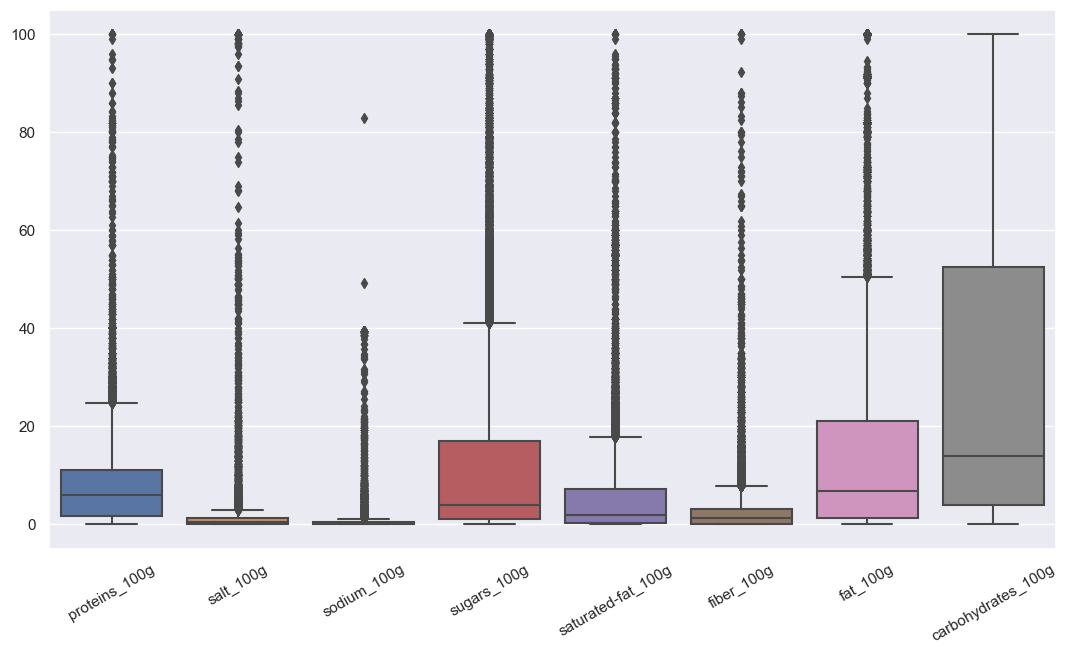

In [163]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [164]:
#plt.figure(figsize=(8, 5))
#boxplot = sm_df.boxplot(column=sm_num_cols)
#plt.xticks(rotation=80)

[Text(0, 0, 'energy_100g')]

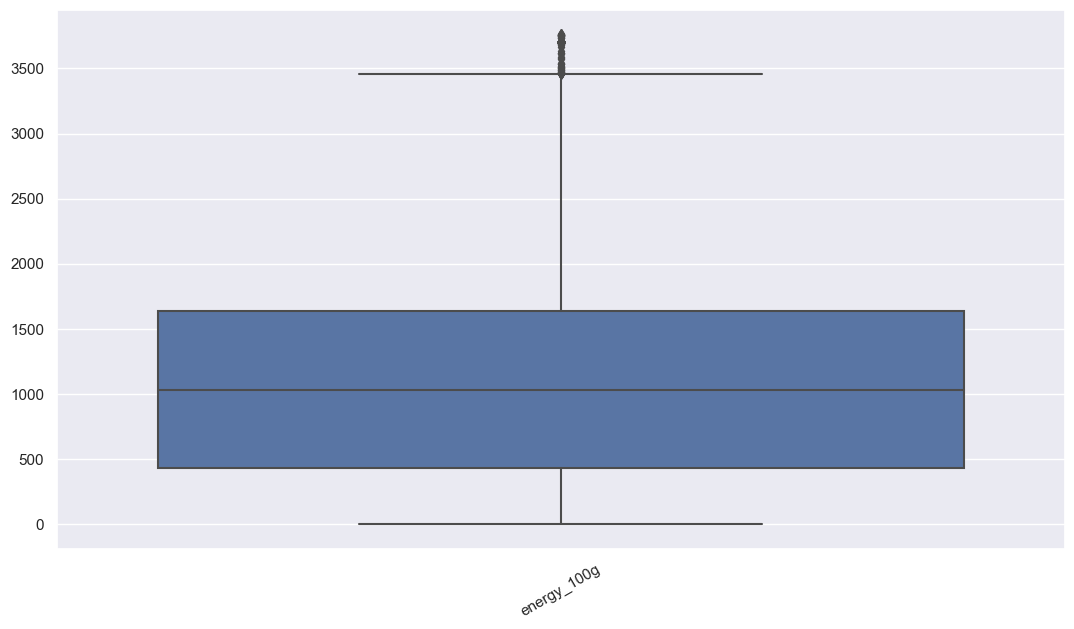

In [165]:
#boxplot = sm_df.boxplot(column=energy_cols)
ax = sns.boxplot(data=sm_df[energy_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'nutrition-score-fr_100g')]

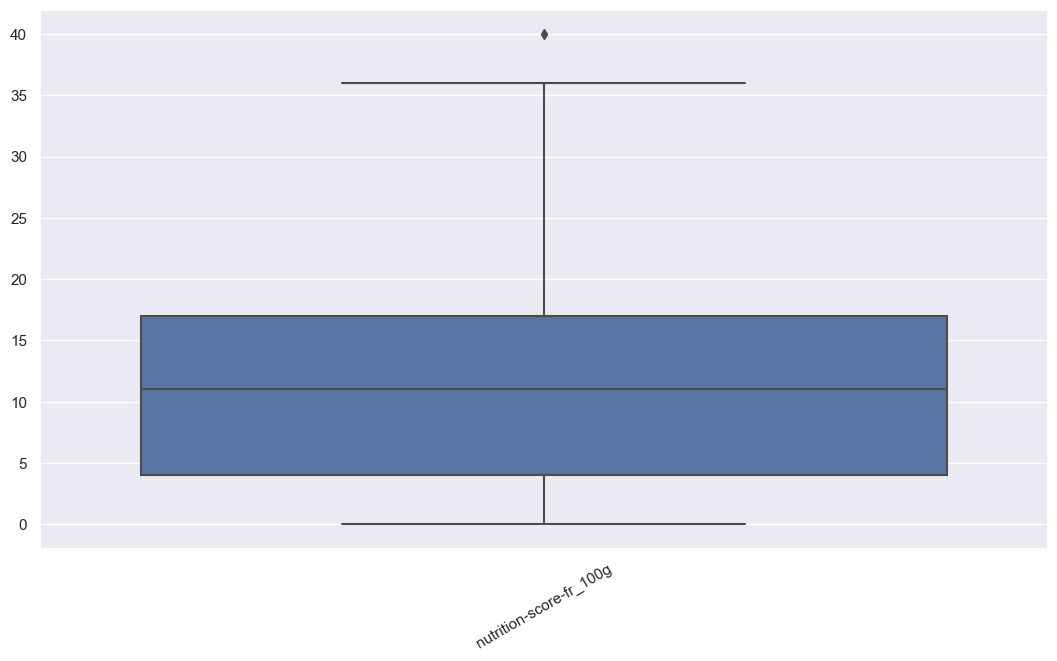

In [166]:
ax = sns.boxplot(data=sm_df[scores_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

#### Checking sum of "per 100g" components

In [167]:
#sm_df['pnns_groups_1'].value_counts()

In [168]:
sm_df[sm_num_cols].head()

,proteins_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
190,0.6,0.0100,0.003937,87.7,0.8,0.9,NaN,NaN
191,9.5,0.0030,0.001181,50.3,2.9,3.9,NaN,NaN
226,0.0,0.0254,0.010000,10.4,0.0,0.0,0.0,10.4
234,7.5,0.8000,0.314961,1.0,11.0,1.4,NaN,NaN
240,0.0,0.1000,0.039370,10.4,0.0,NaN,0.0,10.4


In [169]:
sm_df['comp_sum'] = sm_df[sm_num_cols].sum(axis=1)
sm_df['comp_sum'].head()

190    90.013937
191    66.604181
226    20.835400
234    22.014961
240    20.939370
Name: comp_sum, dtype: float64

In [170]:
comp_sum_100p = sm_df['comp_sum'][sm_df['comp_sum'] > 100]
comp_sum_100p.count()

11419

In [171]:
comp_sum_100p.sort_values(ascending = False)

283105    402.787402
225939    397.795276
225022    390.165354
246934    296.968504
285429    279.685039
             ...    
242410    100.009055
209376    100.008920
204444    100.008661
251691    100.008661
209997    100.007638
Name: comp_sum, Length: 11419, dtype: float64

In [172]:
comp_sum_100p.values

array([114.91984252, 114.00590551, 118.23622047, ..., 131.        ,
       162.48362205, 100.64771654])

<Axes: >

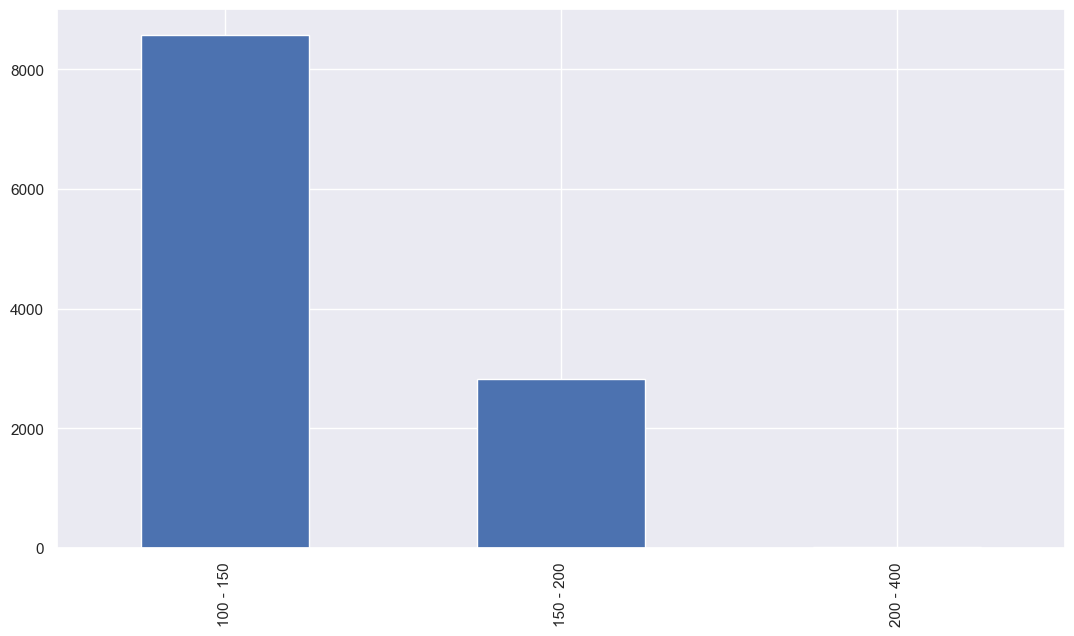

In [173]:
out = pd.cut(comp_sum_100p.values 
             , [100, 150, 200, 400]
             , labels=['100 - 150', '150 - 200', '200 - 400']
            )
out.value_counts().sort_index().plot.bar()

In [174]:
sm_df = sm_df[sm_df['comp_sum'] <= 100]
sm_df.drop('comp_sum', axis = 1, inplace=True)

In [175]:
#sm_df[['pnns_groups_1', 'pnns_groups_2']].fillna('unknown', inplace=True)
#sm_df['pnns_groups_1'].fillna('unknown', inplace=True)

In [176]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,37416.000000,46933.000000,46760.000000,46932.000000,46933.000000,46929.000000,46932.000000,34988.000000,30058.000000,30012.000000
mean,9.368452,8.005150,902.029142,1.032709,0.407618,8.366499,4.259650,2.074272,9.417039,16.343275
std,7.272513,8.164768,665.180770,2.221951,0.903318,14.124037,7.050932,4.090862,12.629693,20.106831
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.530000,347.000000,0.080000,0.031496,0.800000,0.200000,0.000000,1.000000,2.500000
50%,9.000000,5.800000,753.000000,0.650000,0.255906,2.900000,1.400000,1.000000,4.200000,9.500000
75%,15.000000,12.000000,1400.000000,1.300000,0.511811,10.000000,5.000000,2.600000,12.900000,20.500000
max,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [177]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18791     39.976598
pnns_groups_2            18700     39.783002
carbohydrates_100g       16993     36.151473
fat_100g                 16947     36.053611
fiber_100g               12017     25.565365
nutrition-score-fr_100g   9589     20.399957
energy_100g                245      0.521221
product_name               209      0.444634
sugars_100g                 76      0.161685
salt_100g                   73      0.155303
saturated-fat_100g          73      0.155303
proteins_100g               72      0.153175
sodium_100g                 72      0.153175
code                         0      0.000000
nutrition_grade_fr           0      0.000000


### Product names

In [178]:
#drop lines missing product names

In [179]:
sm_df.dropna(axis=0, subset = ['product_name'], inplace = True)

In [196]:
product_count = sm_df['product_name'].value_counts(dropna=False)
product_count_ratio = sm_df['product_name'].value_counts(dropna=False, normalize=True)

In [202]:
product_count.head()

product_name
Mayonnaise                           38
Orange                               34
Moutarde de Dijon                    33
Mayonnaise à la moutarde de Dijon    32
Haricots rouges                      32
Name: count, dtype: int64

In [203]:
product_count_ratio.head()

product_name
Mayonnaise                           0.000822
Orange                               0.000735
Moutarde de Dijon                    0.000713
Mayonnaise à la moutarde de Dijon    0.000692
Haricots rouges                      0.000692
Name: proportion, dtype: float64

In [204]:
sm_df.isna().sum().sum()

92436

In [205]:
sm_df.shape

(46254, 15)

### Barcodes

In [206]:
# https://world.openfoodfacts.org/data/data-fields.txt
#code : barcode of the product (can be EAN-13 or internal codes for some food stores), 
#       for products without a barcode, Open Food Facts assigns a number starting with the 200 reserved prefix


In [207]:
sm_df.shape

(46254, 15)

In [208]:
# count code values
sm_df['code'].count()

46254

In [209]:
# count code values with 200 prefix
sm_df['code'].loc[sm_df['code'].str.startswith('200')].count()

0

In [210]:
sm_df = sm_df.loc[~sm_df['code'].str.startswith('200')]

In [211]:
sm_df.shape

(46254, 15)

### check products nans

In [212]:
sm_df.shape

(46254, 15)

In [213]:
sm_df[sm_df['pnns_groups_1'].isna()].count()

code                       18508
nutrition_grade_fr         18508
nutrition-score-fr_100g    15618
proteins_100g              18484
energy_100g                18348
salt_100g                  18483
sodium_100g                18484
sugars_100g                18482
saturated-fat_100g         18484
product_name               18508
fiber_100g                 17074
fat_100g                    4028
carbohydrates_100g          4013
pnns_groups_2                 88
pnns_groups_1                  0
dtype: int64

In [193]:
sm_df[sm_df['pnns_groups_1'].isna()]

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
190,0000010187319,d,14.0,0.60,1753.0,0.010,0.003937,87.70,0.80,Mini Confettis,0.9,NaN,NaN,NaN,NaN
191,0000010207260,d,14.0,9.50,2406.0,0.003,0.001181,50.30,2.90,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
234,0000069161025,d,15.0,7.50,1079.0,0.800,0.314961,1.00,11.00,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
307,0000606009841,c,6.0,5.80,1272.0,0.700,0.275591,12.70,1.70,Beignets framboises,0.0,NaN,NaN,NaN,NaN
493,00018210,b,1.0,0.30,126.0,0.630,0.248031,2.70,0.80,Carrot & Coriander soup,1.0,1.4,3.6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320690,96087770,d,15.0,10.90,1883.0,0.400,0.157480,34.10,7.80,Peanut & Popcorn With Dark Chocolate 12 x 45G,5.4,NaN,NaN,NaN,NaN
320698,96103890,d,17.0,22.00,1996.0,1.000,0.393701,22.00,10.00,Eat Natural Protein Packed,6.0,NaN,NaN,NaN,NaN
320740,9782211109758,d,16.0,8.70,1084.0,0.290,0.114173,10.50,12.00,Verrine Cheescake Myrtille,0.0,NaN,NaN,NaN,NaN
320741,9782401029101,b,0.0,10.00,4.0,10.000,3.937008,1.00,1.00,Fiche Brevet,10.0,NaN,NaN,NaN,NaN


In [335]:
#sm_df[sm_df['pnns_groups_2'].isna()]

In [336]:
# remove rows with all nutritional values set at NaN

In [337]:
#df.loc[:,2:].isnull().all(1)

In [338]:
sm_df.iloc[:,-2:].isnull().all(1)

190        True
191        True
226       False
234        True
240       False
          ...  
320702    False
320740     True
320741     True
320757     True
320763    False
Length: 46254, dtype: bool

In [204]:
#

#sm_df = sm_df.loc[~sm_df.iloc[:,-2:].isnull().all(1)]

In [205]:
sm_df.shape

(27834, 15)

In [168]:
# check null % of nutri columns regarding who inputed it / which year it has been inputed

## to_remove check

In [169]:
sm_df.describe()

,nutriscore_score,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,35707.000000,34946.000000,35087.000000,35644.000000,35608.000000,35615.000000,35650.000000,35639.000000,35644.000000
mean,8.661411,232.857746,14.123830,5.697903,10.635940,3.279121,12.865959,1.388721,0.561134
std,8.081851,155.971983,14.552291,7.699205,17.220582,6.470352,10.143935,1.967281,0.920148
min,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,116.000000,2.300000,0.600000,0.500000,0.200000,3.600000,0.200000,0.080000
50%,9.000000,203.000000,9.400000,2.600000,2.500000,0.800000,12.000000,1.000000,0.400000
75%,15.000000,341.000000,23.000000,8.400000,12.000000,2.900000,21.000000,1.800000,0.720000
max,35.000000,899.000000,99.900000,95.000000,99.000000,97.000000,99.000000,67.000000,44.000000


In [170]:
sm_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 35707 entries, 102 to 2282492
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                35707 non-null  object 
 1   product_name        35707 non-null  object 
 2   nutriscore_score    35707 non-null  float64
 3   nutriscore_grade    35707 non-null  object 
 4   pnns_groups_1       32065 non-null  object 
 5   energy-kcal_100g    34946 non-null  float64
 6   fat_100g            35087 non-null  float64
 7   saturated-fat_100g  35644 non-null  float64
 8   carbohydrates_100g  35608 non-null  float64
 9   sugars_100g         35615 non-null  float64
 10  proteins_100g       35650 non-null  float64
 11  salt_100g           35639 non-null  float64
 12  sodium_100g         35644 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.8+ MB


In [171]:
sm_num_cols = sm_df.columns[sm_df.dtypes == 'float64']
sm_num_cols

Index(['nutriscore_score', 'energy-kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [172]:
num_100_cols = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
num_kcal_col = ['energy-kcal_100g']

In [173]:
sm_df.nutriscore_score.unique()

array([ 21.,   0.,  14.,   4.,   5.,  28.,  20.,   2.,  22.,  17.,  12.,
        13.,  11.,  19.,   1.,  16.,   3.,  -1.,  15.,  24.,  -4.,  -3.,
         9.,   7.,  -2.,  10.,  -6.,  18.,   8.,   6.,  -7.,  25.,  -5.,
        26.,  23., -10.,  27.,  -8.,  -9.,  29.,  30., -15., -12., -11.,
        35., -13.,  31.])

In [174]:
sm_df["nutriscore_score"] = pd.to_numeric(sm_df["nutriscore_score"], downcast="float")

[Text(0, 0, 'nutriscore_score'),
 Text(1, 0, 'energy-kcal_100g'),
 Text(2, 0, 'fat_100g'),
 Text(3, 0, 'saturated-fat_100g'),
 Text(4, 0, 'carbohydrates_100g'),
 Text(5, 0, 'sugars_100g'),
 Text(6, 0, 'proteins_100g'),
 Text(7, 0, 'salt_100g'),
 Text(8, 0, 'sodium_100g')]

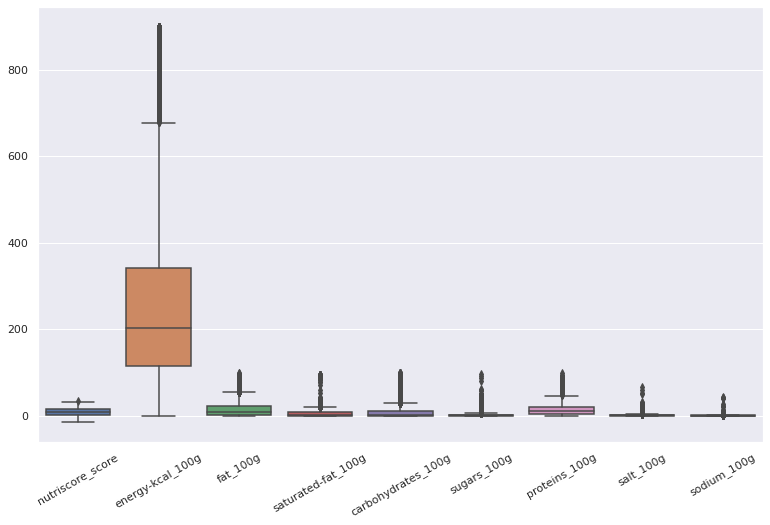

In [175]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

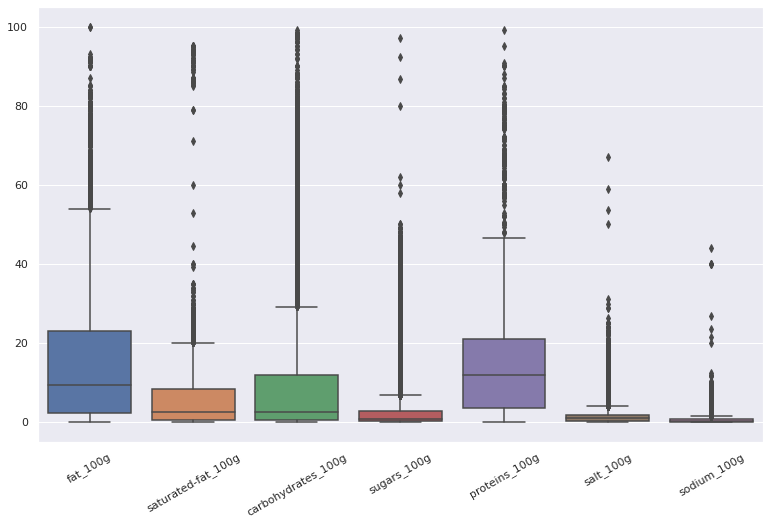

In [176]:
ax = sns.boxplot(data=sm_df[num_100_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


[Text(0, 0, 'energy-kcal_100g')]

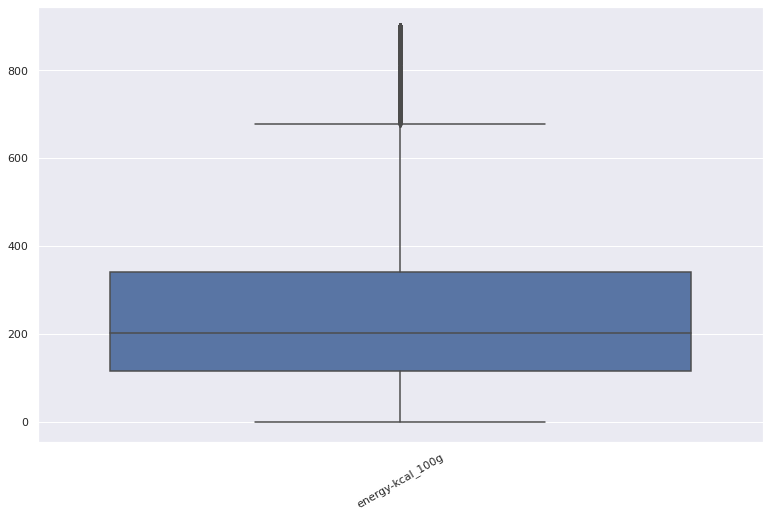

In [177]:
ax = sns.boxplot(data=sm_df[num_kcal_col])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

                               columns  count  null_percent
pnns_groups_1            pnns_groups_1   3642          10.2
energy-kcal_100g      energy-kcal_100g    761           2.1
fat_100g                      fat_100g    620           1.7
carbohydrates_100g  carbohydrates_100g     99           0.3
sugars_100g                sugars_100g     92           0.3
saturated-fat_100g  saturated-fat_100g     63           0.2
proteins_100g            proteins_100g     57           0.2
salt_100g                    salt_100g     68           0.2
sodium_100g                sodium_100g     63           0.2
code                              code      0           0.0
product_name              product_name      0           0.0
nutriscore_score      nutriscore_score      0           0.0
nutriscore_grade      nutriscore_grade      0           0.0


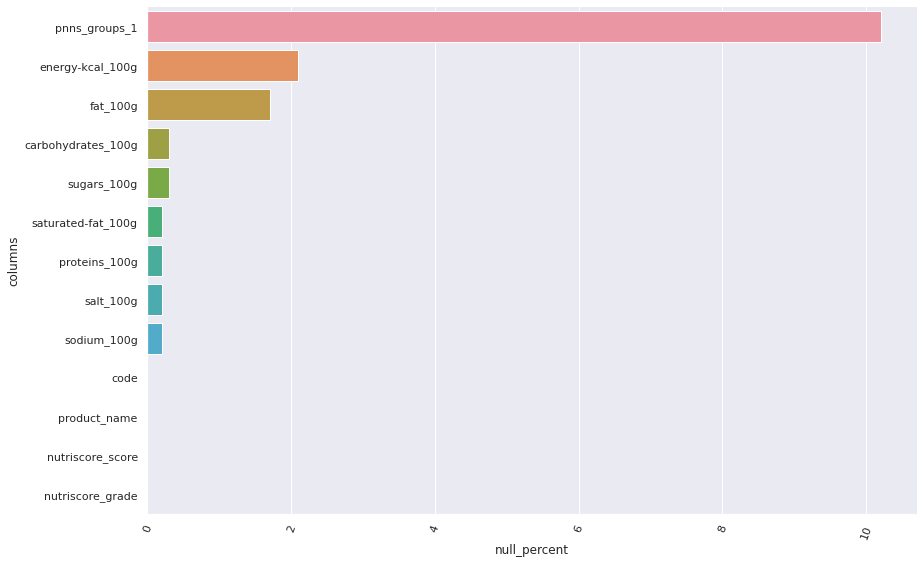

In [178]:
show_nulls(sm_df)

# export to csv

In [179]:
#sm_df.reset_index()

#sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
#print('export finished !')

In [180]:

#sm_df.reset_index()

sm_df.to_csv(path + 'to_input_openfoodfacts.csv', index=False)
print('export finished !')

export finished !


In [181]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août   2022 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 3,5M 12 avril 08:50 clean_openfoodfacts_3.csv
-rw-r--r-- 1 mijka mijka 166M  3 août   2022 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 3,5M 31 mars  11:50 clean_openfoodfacts_x.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril  2022 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril  2022 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv
-rw-r--r-- 1 mijka mijka 3,5M 10 mai   11:55 to_input_openfoodfacts.csv


In [ ]:
sm_df['pnns_groups_1'].unique()

# Imputing

In [ ]:
# => moving importing to a different notebook to reduce memory usage of the whole process.

In [ ]:
all_cols = sm_df.columns
all_cols


In [ ]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [ ]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats


In [ ]:
all_cols

In [ ]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

In [ ]:
#groupby pnns_groups_1, mean, remplir avec mean / categorie
#list1 = ["fat_100g", "salt_100g"]
main_cats

In [ ]:
sm_df.filter(main_cats).head()

In [ ]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")